# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Import human data

In [2]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_word_recognition_short*/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

200

In [3]:
any(["654110840e6a9717486c8aa2" in name.stem for name in human_fnames])

True

## Process Human Results

In [4]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 
results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/Auditory-Attention/human_saddler_attn_expmt_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k:02}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, snr = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        # print(stim_str)
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            condition, snr = stim_cond_map[cond_str]
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            snr = np.inf
    return snr, condition

# add as columns 
results_df['snr'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                       "babble":"background_cv08talkerbabble",
                       "stationary": "background_issnstationary",
                       "modulated": "background_issnfestenplomp",
                       "audioset": "background_audioset",
                       "natural scene": "background_ieeeaaspcasa",
                       "clean": "SILENCE"}

condition_map = {v:k for k,v in test_condition_dict.items()}
trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
total_trials = 192 
full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() == total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


Unterminated string starting at: line 1 column 72026 (char 72025)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6533ba7daced485bbd50324c.json
Unterminated string starting at: line 1 column 84036 (char 84035)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_6393f158851fb438d2ceb5d7.json
Unterminated string starting at: line 1 column 300481 (char 300480)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_64275d22f204d1161ad23e64.json
Unterminated string starting at: line 1 column 300457 (char 300456)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_631ffc3584141f143567f021.json
Unterminated string starting at: line 1 column 168069 (char 168068)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_word_recognition_short/data/subj_5978f6f009bdcf000153f43d.json
Expecting ',' delimiter: line 1 column 24016 (char 24015)
/mindh

/tmp/ipykernel_1260090/3373245867.py:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['condition'] = trial_results['condition'].replace(condition_map)
/tmp/ipykernel_1260090/3373245867.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trial_results['accuracy'] = (trial_results['response'] == trial_results['correct_response']).astype('int')


In [5]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
# catch_trial_particiapnt_performance

In [58]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 11/12].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]

N total participants  96
N good participants  81


In [59]:
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response.isna())]
analysis_df.groupby('id_subject').condition.count()

id_subject
545d347afdf99b7f9fca22c7    192
56f81ffe1b99b8000636b9c8    192
5714e0958adadb00098deed4    192
57d0db6cf7bcd90001cd47bc    192
57e17bdc1334540001170aa0    192
                           ... 
65269c98d6fe44c6fc33119b    192
653fbcaaa78ddad682898a63    192
65410d5bb6f25eb9988b5c4b    192
65431504ce1bb7aa6394fd75    192
654517983282e9e8d26ce207    192
Name: condition, Length: 81, dtype: int64

## Add re-scored performance based on entries included in excerpt transcripts  

In [54]:
manifests[manifests.base_str == 'stim/condition_39/346.wav']

,target_sr,experiment_key_target_word_ix,cue_sr,target_fn,cue_fn,word,word_int,condition,snr,src_ix,...,target_gender,target_f0,mixture_fn,target_transcript,distractor_fn,distractor_f0,distractor_gender,distractor_word,distractor_transcript,base_str


In [52]:
w_tscrpt[w_tscrpt.target_transcript.isna()].stimulus

1        stim/condition_39/346.wav
3        stim/condition_08/348.wav
7        stim/condition_37/328.wav
10       stim/condition_10/329.wav
13       stim/condition_33/349.wav
                   ...            
15540    stim/condition_19/355.wav
15542    stim/condition_26/358.wav
15544    stim/condition_00/339.wav
15548    stim/condition_27/357.wav
15550    stim/condition_08/334.wav
Name: stimulus, Length: 2652, dtype: object

In [60]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

# manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_single_distractor_ground_truth_manifest.pdpkl")
manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_all_condition_ground_truth_manifest.pdpkl")


analysis_df = pd.merge(analysis_df,
                        manifests[['base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                                    left_on='stimulus', right_on='base_str', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcript.values
distractor_transcripts = analysis_df.distractor_transcript.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

f0_analysis_df = analysis_df[analysis_df.condition.isin([ "1-talker", 'clean'])]
f0_analysis_df['gender_cond'] = f0_analysis_df['target_gender'].values == f0_analysis_df['distractor_gender'].values
f0_analysis_df['gender_cond'] = f0_analysis_df['gender_cond'].replace({True: 'same', False: 'different'})
f0_analysis_df["abs_f0_diff"] = np.abs(f0_analysis_df.target_f0 - f0_analysis_df.distractor_f0)
f0_analysis_df["percent_f0_diff"] = f0_analysis_df.distractor_f0 / f0_analysis_df.target_f0 
    
# rename condition to background condition
f0_analysis_df = f0_analysis_df.rename(columns={"condition": "background_condition"})
f0_analysis_df = f0_analysis_df.dropna(axis=1,  how = 'all')
# get columns with trial in their name
trial_cols = [col for col in f0_analysis_df.columns if 'trial' in col]
# drop trial columns
f0_analysis_df = f0_analysis_df.drop(columns=trial_cols).reset_index(drop=True)


/tmp/ipykernel_1260090/1139381997.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df['gender_cond'] = f0_analysis_df['target_gender'].values == f0_analysis_df['distractor_gender'].values
/tmp/ipykernel_1260090/1139381997.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f0_analysis_df['gender_cond'] = f0_analysis_df['gender_cond'].replace({True: 'same', False: 'different'})
/tmp/ipykernel_1260090/1139381997.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [61]:
# get trial data excluding catch trials 


part_summary_df = (analysis_df.groupby(["snr", 'id_subject', "condition"])
                     .agg({'correct':['mean', 'sem', 'count'],
                            'confusions':['mean', 'sem', 'count'],
                            'adjusted_accuracy':['mean', 'sem', 'count'],
                            'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]


In [62]:
part_summary_df.head()

,snr,id_subject,condition,correct_mean,correct_sem,correct_count,confusions_mean,confusions_sem,confusions_count,adjusted_accuracy_mean,adjusted_accuracy_sem,adjusted_accuracy_count,adjusted_confusions_mean,adjusted_confusions_sem,adjusted_confusions_count
0,-9,545d347afdf99b7f9fca22c7,1-talker,0.4,0.244949,5,0.0,0.0,5,0.6,0.244949,5,0.0,0.0,5
1,-9,545d347afdf99b7f9fca22c7,4-talker,0.0,0.000000,5,0.0,0.0,5,0.0,0.000000,5,NaN,NaN,0
2,-9,545d347afdf99b7f9fca22c7,babble,0.0,0.000000,5,0.0,0.0,5,0.0,0.000000,5,NaN,NaN,0
3,-9,545d347afdf99b7f9fca22c7,modulated,0.2,0.200000,5,0.0,0.0,5,0.4,0.244949,5,NaN,NaN,0
4,-9,545d347afdf99b7f9fca22c7,music,0.0,0.000000,5,0.0,0.0,5,0.4,0.244949,5,NaN,NaN,0


In [63]:
## Summarize participant data for aggregate plotting

summary_df = part_summary_df.groupby(['snr', 'condition']).agg({'correct_mean':['mean', 'sem'], 'confusions_mean':['mean', 'sem', 'count'],
                                                             'adjusted_accuracy_mean':['mean','sem'], 'adjusted_confusions_mean':['mean', 'sem']}).reset_index()
summary_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error']


## Load Model Results 

In [64]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [65]:
# manifests[manifests.condition == 'clean'].snr.iloc[0]

In [73]:
manifests.background_condition

AttributeError: 'DataFrame' object has no attribute 'background_condition'

In [83]:

model_names = ["word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
model_name_dict = {"attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor": "WordSpeakerNoise", "word_task_mono_arch_v06": "CommonVoice"}

all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 
manifests["background_condition"] = manifests.condition.replace(str_to_cond, )

for model_name in model_names:
    if model_name == "word_task_mono_arch_v06":
        output_paths = list(Path(f'swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))

    elif model_name == "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor":
        output_paths = list(Path(f'../Auditory-Attention/swc_mono_eval/{model_name}').glob('*.csv'))
        print(len(output_paths))
    results_dfs = []


    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')       
        if "background" in path.stem:
            df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
        else:
            df['background_condition'] = parts[1]
        if 'SILENCE' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        results_dfs.append(df)
    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word = cv_class_2_word if 'CommonVoice' == model_str else wsn_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # Add 1-talker condition metadata to model results
    model_results = pd.merge(model_results,
            manifests[["background_condition", "snr", "word", "word_int", 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                        left_on=['background_condition', 'snr', "true_word"], right_on=["background_condition", "snr",  "word"], how='left')


    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # add adjusted accuracy and confusions 
    target_words = model_results.pred_word.values
    target_transcripts = model_results.target_transcript.values
    distractor_transcripts = model_results.distractor_transcript.values


    adjusted_acc = np.array([int(target_word in target_transcript)
                                if not isinstance(target_transcript, float) else np.nan
                                for target_word, target_transcript in zip(target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(target_word in distractor_transcript)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)

    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
    model_f0_df.loc[model_f0_df.background_condition == 'clean', 'gender_cond'] = 'clean'
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)

41


/tmp/ipykernel_1260090/3674207663.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_1260090/3674207663.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_1260090/3674207663.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

41


/tmp/ipykernel_1260090/3674207663.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
/tmp/ipykernel_1260090/3674207663.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
/tmp/ipykernel_1260090/3674207663.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [84]:
# all_model_results[all_model_results.condition == 'clean']

In [85]:
summary_df['group'] = 'participants'
# model_results['group'] = 'model'

# combine model and participant results ignore missing columns
combined_results = pd.concat([summary_df, all_model_results], axis=0, ignore_index=True)

In [86]:
combined_results.loc[combined_results.snr == np.inf, 'snr'] = 6
combined_results.loc[combined_results.snr == 'inf', 'snr'] = 6
combined_results.snr = combined_results.snr.astype('int')

## Standard analysis 

(0.0, 1.0)

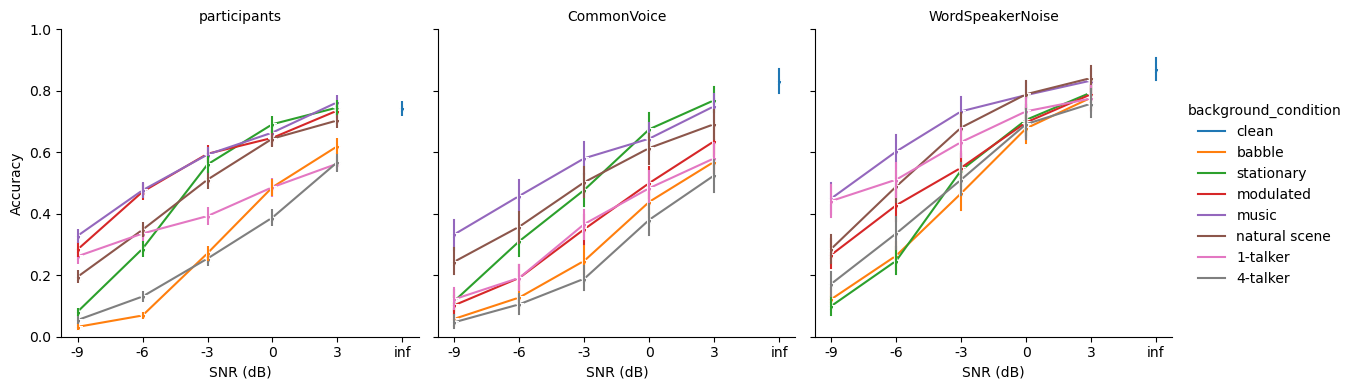

In [87]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model == 'model':
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
# plt.suptitle(f"Using single-word accuracy", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using whole-transcript accuracy')

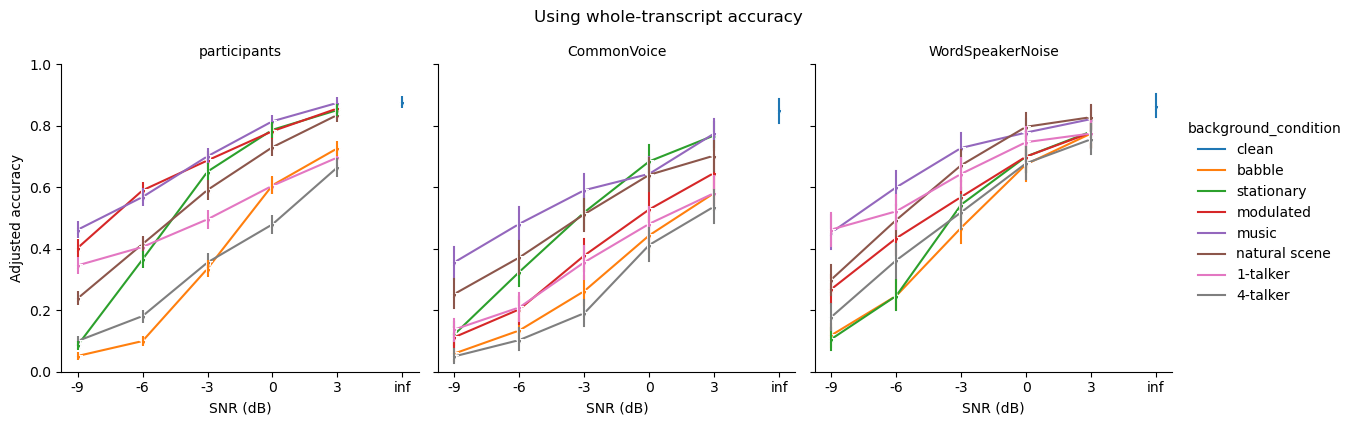

In [88]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]

palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))


# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Adjusted accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above 
    if model == 'model':
        continue 
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)
plt.suptitle(f"Using whole-transcript accuracy", y=1.05)
# plt.tight_layout()

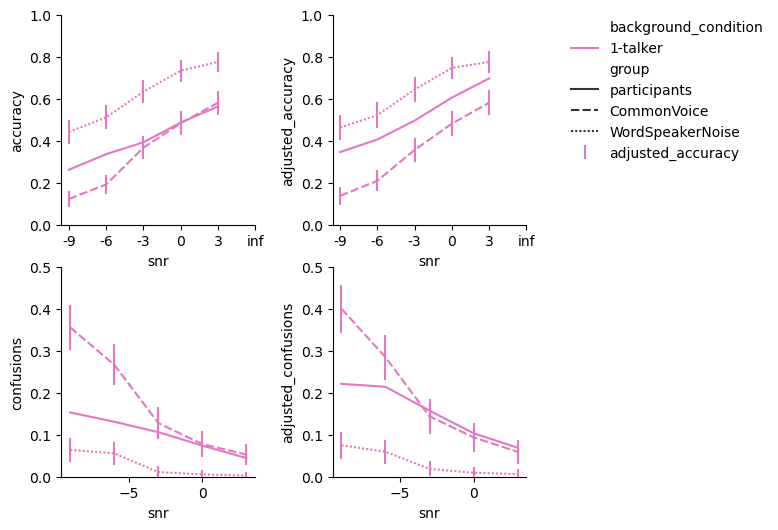

In [89]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

to_plot = combined_results[combined_results.background_condition.isin(["1-talker"])]
# to_plot = to_plot.drop(columns=['target_transcript', 'distractor_transcript'])
# to_plot.drop_duplicates(inplace=True)



g = sns.lineplot(data=to_plot, x = 'snr', y = 'accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=['participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='background_condition', palette=palette,
            ax=axs[0,0])

g1 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_accuracy',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=['participants', 'CommonVoice', 'WordSpeakerNoise'], 
                   hue='background_condition', palette=palette,
            ax=axs[0,1])


g2 = sns.lineplot(data=to_plot, x = 'snr', y = 'confusions', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=['participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='background_condition', palette=palette,
            ax=axs[1,0])

g3 = sns.lineplot(data=to_plot, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=['participants', 'CommonVoice', 'WordSpeakerNoise'], 
                   hue='background_condition', palette=palette,
            ax=axs[1,1])

# add error bars for participants
# iterate through each facet of the facetgrid
ebar_data = to_plot[to_plot['group'].eq('participants')]
# select the data for each hue group
g.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g2.errorbar(data=selected, x="snr", y="confusions", yerr="conf_std_error", color=palette["1-talker"], marker=None, ls='none' )

g1.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette["1-talker"], marker=None, ls='none' )
g3.errorbar(data=selected, x="snr", y="adjusted_confusions", yerr="adj_conf_std_error", color=palette["1-talker"], marker=None, ls='none' )


g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels) # adj_acc_std_error
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g2.set_ylim(0,.5)
g3.set_ylim(0,.5)

g.legend().remove()     
g2.legend().remove()
g3.legend().remove()

# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(1.2, 1), loc=2, borderaxespad=0., title='')


### Scatter plot of human vs model performance

In [90]:
from scipy import stats


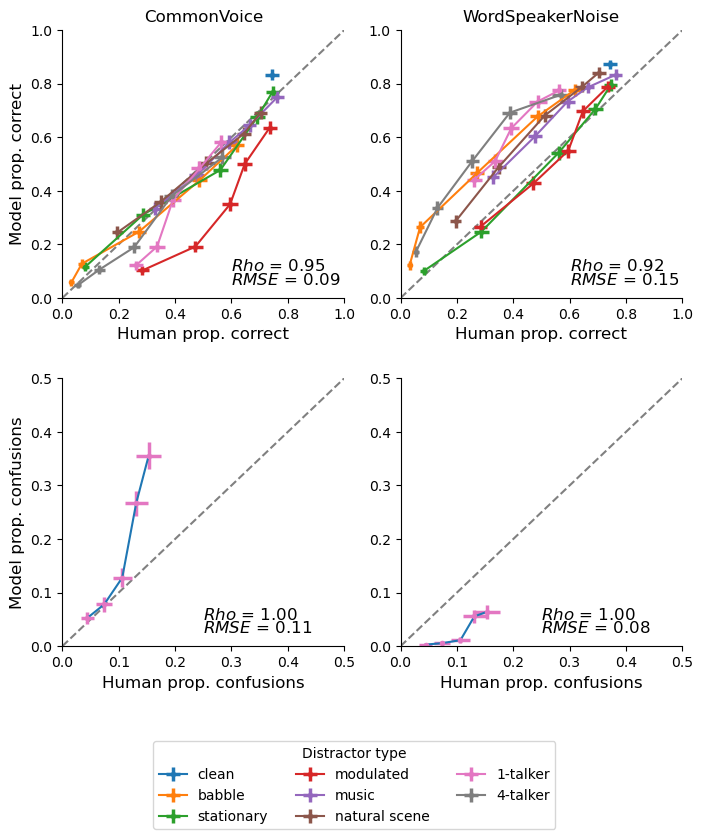

In [91]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 12

fig, axs = plt.subplots(2,2, figsize=(8,8))

# for ix, group in enumerate(grouped_results.group.unique()):
axs[0,0].plot(x,y, ls='dashed', color='grey')
axs[0,1].plot(x,y, ls='dashed', color='grey')
axs[1,0].plot(x,y, ls='dashed', color='grey')
axs[1,1].plot(x,y, ls='dashed', color='grey')
    # axs[1,ix].plot(x,y, ls='dashed', color='grey')
cv_model_df = grouped_results[grouped_results.group == 'CommonVoice']
# summarize model data
cv_model_df = cv_model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
cv_model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']

wsn_model_df = grouped_results[grouped_results.group == 'WordSpeakerNoise']
# summarize model data
wsn_model_df = wsn_model_df.groupby(['snr', 'background_condition']).agg({'accuracy': ['mean', 'sem',], 'confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
wsn_model_df.columns = ['snr', 'background_condition', 'accuracy', 'acc_std_error', 'confusions', 'conf_std_error', 'N']

human_df = grouped_results[grouped_results.group == 'participants']

for condition in hue_order:
    # plot acc 
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["accuracy"].values
    human_errors = human_data["acc_std_error"].values

    cv_model_data = cv_model_df[cv_model_df.background_condition == condition]
    cv_model_means = cv_model_data["accuracy"].values
    cv_model_errors = cv_model_data["acc_std_error"].values

    wsn_model_data = wsn_model_df[wsn_model_df.background_condition == condition]
    wsn_model_means = wsn_model_data["accuracy"].values
    wsn_model_errors = wsn_model_data["acc_std_error"].values

    axs[0,0].errorbar(x=human_means, y=cv_model_means, xerr=human_errors, yerr=cv_model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        ecolor=palette[condition], mfc=palette[condition], mec=palette[condition])
    
    axs[0,1].errorbar(x=human_means, y=wsn_model_means, xerr=human_errors, yerr=wsn_model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        ecolor=palette[condition], mfc=palette[condition], mec=palette[condition])

# # plot confusions
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["confusions"].values
human_conf_errors = human_conf_data["conf_std_error"].values

# cv model confusions
cv_model_conf_data = cv_model_df[cv_model_df.background_condition ==  "1-talker"]
cv_model_conf_means = cv_model_conf_data["confusions"].values
cv_model_conf_errors = cv_model_conf_data["conf_std_error"].values

# wsn model confusions
wsn_model_conf_data = wsn_model_df[wsn_model_df.background_condition ==  "1-talker"]
wsn_model_conf_means = wsn_model_conf_data["confusions"].values
wsn_model_conf_errors = wsn_model_conf_data["conf_std_error"].values

axs[1,0].errorbar(x=human_conf_means, y=cv_model_conf_means, xerr=human_conf_errors, yerr=cv_model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                    ecolor=palette[ "1-talker"], mfc=palette[ "1-talker"], mec=palette[ "1-talker"])
        
axs[1,1].errorbar(x=human_conf_means, y=wsn_model_conf_means, xerr=human_conf_errors, yerr=wsn_model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                    ecolor=palette[ "1-talker"], mfc=palette[ "1-talker"], mec=palette[ "1-talker"])

        
# set first row x and y limits to 0 1

axs[0,0].set_xlim(0,1)
axs[0,1].set_xlim(0,1)
axs[0,0].set_ylim(0,1)
axs[0,1].set_ylim(0,1)

axs[1,0].set_xlim(0,0.5)
axs[1,1].set_xlim(0,0.5)
axs[1,0].set_ylim(0,0.5)
axs[1,1].set_ylim(0,0.5)

axs[0,0].set_xlabel(f"Human prop. correct", fontsize=fontsize)
axs[1,0].set_xlabel(f"Human prop. confusions", fontsize=fontsize)
axs[0,1].set_xlabel(f"Human prop. correct", fontsize=fontsize)
axs[1,1].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

axs[0,0].set_title(f"CommonVoice", fontsize=fontsize)
axs[0,1].set_title(f"WordSpeakerNoise", fontsize=fontsize)

# acc errors 
res = stats.spearmanr(human_df["accuracy"].values,  cv_model_df['accuracy'].values)
rho = res.statistic
axs[0,0].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.1), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - cv_model_df['accuracy'].values)**2))
axs[0,0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

# conf errors 
# acc errors 
res = stats.spearmanr(human_df["accuracy"].values,  wsn_model_df['accuracy'].values)
rho = res.statistic
axs[0,1].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.1), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_df["accuracy"].values - wsn_model_df['accuracy'].values)**2))
axs[0,1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

# conf errors 
res = stats.spearmanr(human_conf_means, cv_model_conf_means)
rho = res.statistic
axs[1,0].annotate(f"$Rho$ = {rho:.2f}", (0.25, 0.05), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_conf_means - cv_model_conf_means)**2))
axs[1,0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.25, 0.025), fontsize=fontsize)
# conf errors 
res = stats.spearmanr(human_conf_means, wsn_model_conf_means)
rho = res.statistic
axs[1,1].annotate(f"$Rho$ = {rho:.2f}", (0.25, 0.05), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_conf_means - wsn_model_conf_means)**2))
axs[1,1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.25, 0.025), fontsize=fontsize)


axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)
sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()
# 

# plt.suptitle(f"Using strict scoring", y=0.95)



Text(0.5, 0.95, 'Using adjusted scoring')

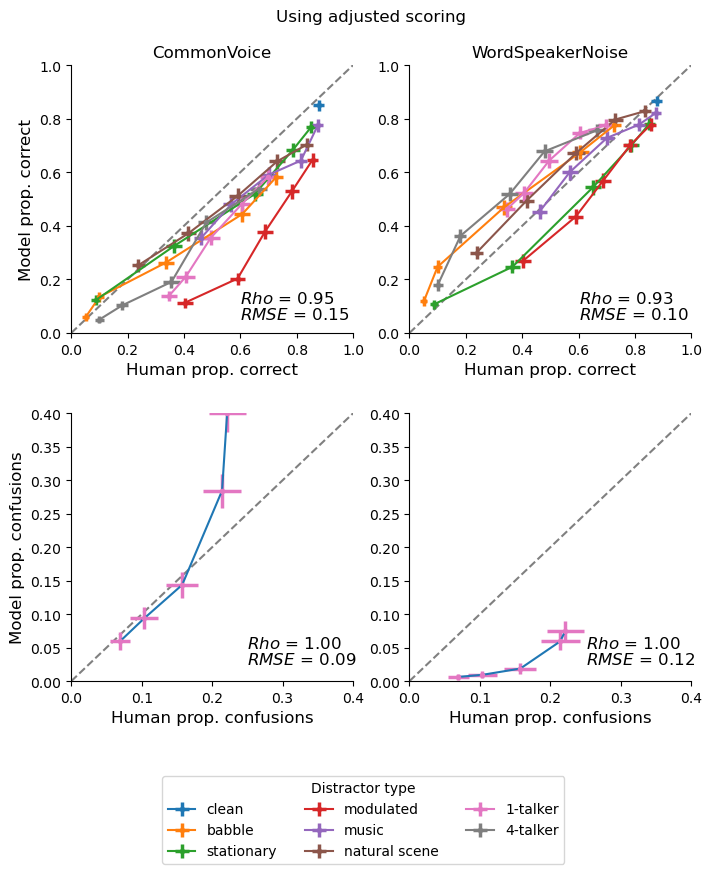

In [92]:
grouped_results = combined_results[~combined_results.background_condition.isin(["catch_trial", 'audioset'])]

hue_order = ['clean', 'babble',  'stationary', 'modulated', 'music', 'natural scene', "1-talker", "4-talker"]
palette = dict(zip(hue_order, sns.color_palette(n_colors= len(hue_order), as_cmap=True)))

x = y = np.linspace(0,1,5)

fontsize = 12

fig, axs = plt.subplots(2,2, figsize=(8,8))

# for ix, group in enumerate(grouped_results.group.unique()):
axs[0,0].plot(x,y, ls='dashed', color='grey')
axs[0,1].plot(x,y, ls='dashed', color='grey')
axs[1,0].plot(x,y, ls='dashed', color='grey')
axs[1,1].plot(x,y, ls='dashed', color='grey')
    # axs[1,ix].plot(x,y, ls='dashed', color='grey')
cv_model_df = grouped_results[grouped_results.group == 'CommonVoice']
# summarize model data
cv_model_df = cv_model_df.groupby(['snr', 'background_condition']).agg({'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
cv_model_df.columns = ['snr', 'background_condition', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']

wsn_model_df = grouped_results[grouped_results.group == 'WordSpeakerNoise']
# summarize model data
wsn_model_df = wsn_model_df.groupby(['snr', 'background_condition']).agg({'adjusted_accuracy': ['mean', 'sem',], 'adjusted_confusions':['mean', 'sem', 'count']}).reset_index()
# rename columns
wsn_model_df.columns = ['snr', 'background_condition', 'adjusted_accuracy', 'adj_acc_std_error', 'adjusted_confusions', 'adj_conf_std_error', 'N']

human_df = grouped_results[grouped_results.group == 'participants']

for condition in hue_order:
    # plot acc 
    human_data = human_df[human_df.background_condition == condition]
    human_means = human_data["adjusted_accuracy"].values
    human_errors = human_data["adj_acc_std_error"].values

    cv_model_data = cv_model_df[cv_model_df.background_condition == condition]
    cv_model_means = cv_model_data["adjusted_accuracy"].values
    cv_model_errors = cv_model_data["adj_acc_std_error"].values

    wsn_model_data = wsn_model_df[wsn_model_df.background_condition == condition]
    wsn_model_means = wsn_model_data["adjusted_accuracy"].values
    wsn_model_errors = wsn_model_data["adj_acc_std_error"].values

    axs[0,0].errorbar(x=human_means, y=cv_model_means, xerr=human_errors, yerr=cv_model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        ecolor=palette[condition], mfc=palette[condition], mec=palette[condition])
    
    axs[0,1].errorbar(x=human_means, y=wsn_model_means, xerr=human_errors, yerr=wsn_model_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                        ecolor=palette[condition], mfc=palette[condition], mec=palette[condition])

# # plot adjusted_confusions
human_conf_data = human_df[human_df.background_condition ==  "1-talker"]
human_conf_means = human_conf_data["adjusted_confusions"].values
human_conf_errors = human_conf_data["adj_conf_std_error"].values

# cv model adjusted_confusions
cv_model_conf_data = cv_model_df[cv_model_df.background_condition ==  "1-talker"]
cv_model_conf_means = cv_model_conf_data["adjusted_confusions"].values
cv_model_conf_errors = cv_model_conf_data["adj_conf_std_error"].values

# wsn model adjusted_confusions
wsn_model_conf_data = wsn_model_df[wsn_model_df.background_condition ==  "1-talker"]
wsn_model_conf_means = wsn_model_conf_data["adjusted_confusions"].values
wsn_model_conf_errors = wsn_model_conf_data["adj_conf_std_error"].values

axs[1,0].errorbar(x=human_conf_means, y=cv_model_conf_means, xerr=human_conf_errors, yerr=cv_model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                    ecolor=palette[ "1-talker"], mfc=palette[ "1-talker"], mec=palette[ "1-talker"])
        
axs[1,1].errorbar(x=human_conf_means, y=wsn_model_conf_means, xerr=human_conf_errors, yerr=wsn_model_conf_errors, marker='o', linestyle='-', ms=3, elinewidth=2.5, label= "1-talker",
                    ecolor=palette["1-talker"], mfc=palette[ "1-talker"], mec=palette[ "1-talker"])

        
# set first row x and y limits to 0 1

axs[0,0].set_xlim(0,1)
axs[0,1].set_xlim(0,1)
axs[0,0].set_ylim(0,1)
axs[0,1].set_ylim(0,1)

axs[1,0].set_xlim(0,0.4)
axs[1,1].set_xlim(0,0.4)
axs[1,0].set_ylim(0,0.4)
axs[1,1].set_ylim(0,0.4)

axs[0,0].set_xlabel(f"Human prop. correct", fontsize=fontsize)
axs[1,0].set_xlabel(f"Human prop. confusions", fontsize=fontsize)
axs[0,1].set_xlabel(f"Human prop. correct", fontsize=fontsize)
axs[1,1].set_xlabel(f"Human prop. confusions", fontsize=fontsize)

axs[0,0].set_title(f"CommonVoice", fontsize=fontsize)
axs[0,1].set_title(f"WordSpeakerNoise", fontsize=fontsize)

# acc errors 
res = stats.spearmanr(human_df["adjusted_accuracy"].values,  cv_model_df['adjusted_accuracy'].values)
rho = res.statistic
axs[0,0].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - cv_model_df['adjusted_accuracy'].values)**2))
axs[0,0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

# conf errors 
# acc errors 
res = stats.spearmanr(human_df["adjusted_accuracy"].values,  wsn_model_df['adjusted_accuracy'].values)
rho = res.statistic
axs[0,1].annotate(f"$Rho$ = {rho:.2f}", (0.6, 0.11), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_df["adjusted_accuracy"].values - wsn_model_df['adjusted_accuracy'].values)**2))
axs[0,1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.6, 0.05), fontsize=fontsize)

# conf errors 
res = stats.spearmanr(human_conf_means, cv_model_conf_means)
rho = res.statistic
axs[1,0].annotate(f"$Rho$ = {rho:.2f}", (0.25, 0.05), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_conf_means - cv_model_conf_means)**2))
axs[1,0].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.25, 0.025), fontsize=fontsize)
# conf errors 
res = stats.spearmanr(human_conf_means, wsn_model_conf_means)
rho = res.statistic
axs[1,1].annotate(f"$Rho$ = {rho:.2f}", (0.25, 0.05), fontsize=fontsize)
samp_rmse = np.sqrt(np.mean((human_conf_means - wsn_model_conf_means)**2))
axs[1,1].annotate(f"$RMSE$ = {samp_rmse:.2f}", (0.25, 0.025), fontsize=fontsize)


axs[0,0].set_ylabel(f"Model prop. correct", fontsize=fontsize)
axs[1,0].set_ylabel(f"Model prop. confusions", fontsize=fontsize)
sns.despine()
lines_labels = [ax.get_legend_handles_labels() for ax in [axs[0,0]]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
plt.subplots_adjust(hspace=0.3)

fig.legend(lines, hue_order, bbox_transform=fig.transFigure, ncol=3, title='Distractor type',  bbox_to_anchor=(0.75, 0),)
# plt.tight_layout()
# 

plt.suptitle(f"Using adjusted scoring", y=0.95)



Text(0.5, 1.05, 'Using Kell/Saddler conditions: middle word accuracy')

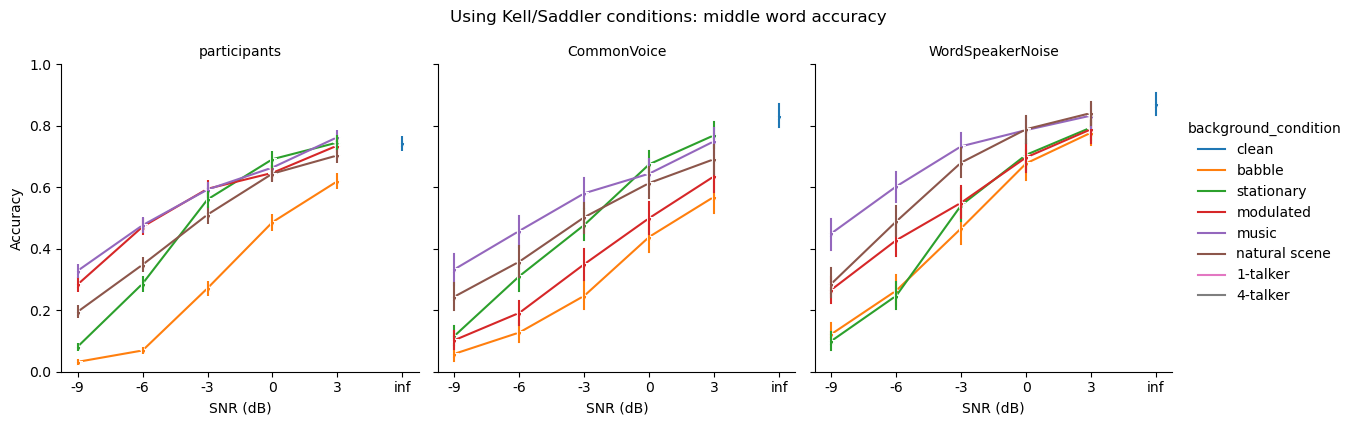

In [132]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                err_style='bars', errorbar=('ci', 95),
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using Kell/Saddler conditions: middle word accuracy", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Using Kell/Saddler conditions: in-transcript accuracy')

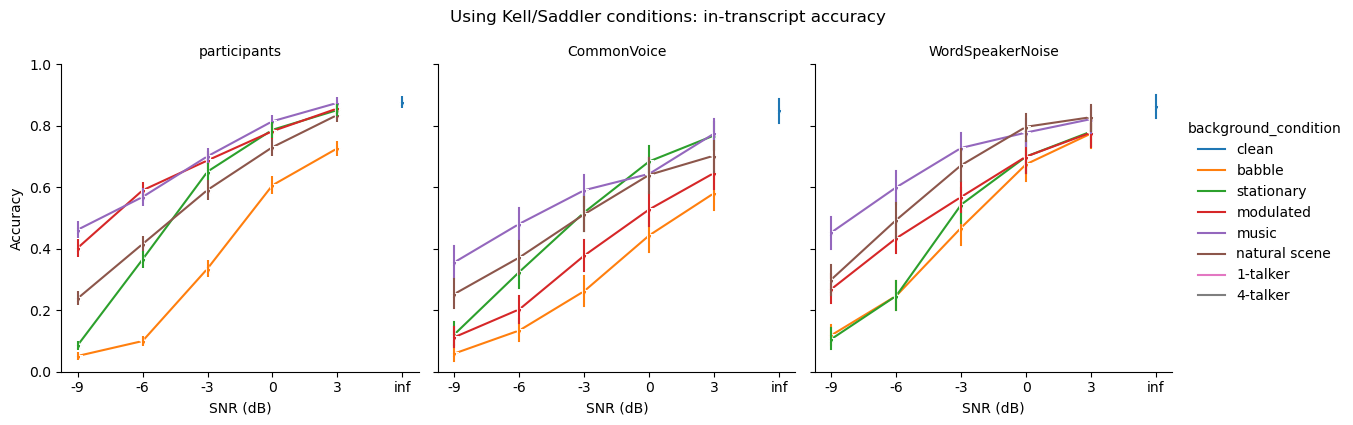

In [133]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = combined_results[~combined_results.background_condition.isin(["catch_trial", "1-talker", "4-talker", "audioset"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# plt.figure(figsize=(2,2))
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                err_style='bars', errorbar=('ci', 95),
                  kind='line', marker='*', palette=palette, height=4, aspect=1)
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Using Kell/Saddler conditions: in-transcript accuracy", y=1.05)

# plt.tight_layout()

Text(0.5, 1.05, 'Conditions used in TIMIT experiment: middle word accuracy')

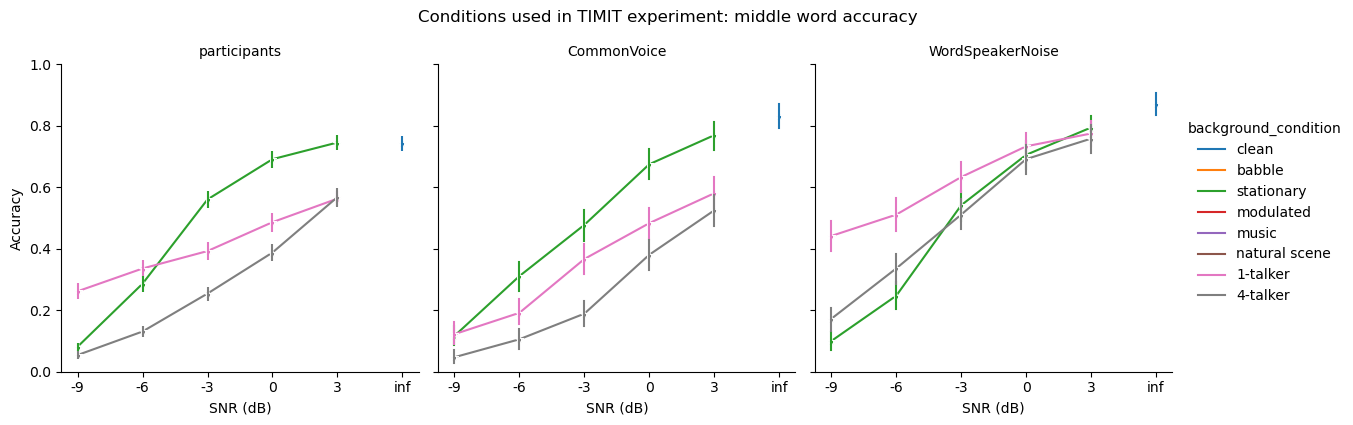

In [131]:

# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot_list = ["1-talker", "4-talker", "clean", "babble"]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker", "4-talker", "clean", "stationary"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above
    if model == 'model':
        continue
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="accuracy", yerr="acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Conditions used in TIMIT experiment: middle word accuracy", y=1.05)


# plt.tight_layout()

Text(0.5, 1.05, 'Conditions used in TIMIT experiment: in-transcript accuracy')

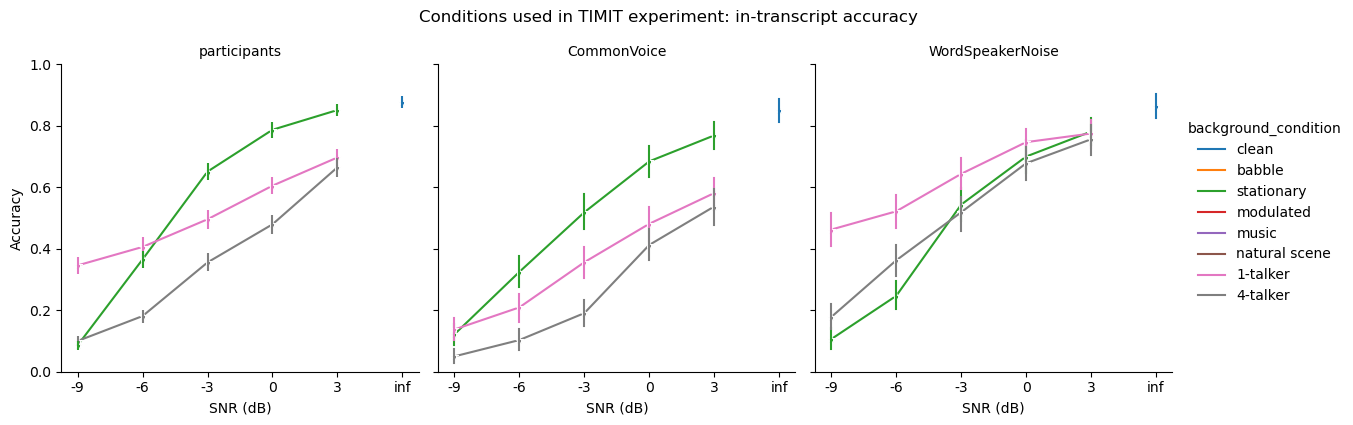

In [129]:
# part_summary_df.rename(columns={'mean': 'accuracy', 'condition': "
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot_list = ["1-talker", "4-talker", "clean", "babble"]
to_plot = combined_results[combined_results.background_condition.isin(["1-talker", "4-talker", "clean", "stationary"])]
# palette = dict(zip(to_plot.background_condition.unique(), sns.color_palette(n_colors= len(to_plot.background_condition.unique()), as_cmap=True)))

# add markers to relplot
# add markers to relplot
g = sns.relplot(data=to_plot, x='snr', y='adjusted_accuracy', col='group', hue='background_condition', hue_order=hue_order,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                  kind='line', marker='*', palette=palette, height=4, aspect=1, err_style='bars', errorbar=('ci', 95))
# g.map(plt.errorbar, "snr", "accuracy", "std_error", marker=None, ls='none')

# set labels 
g.set_axis_labels("SNR (dB)", "Accuracy")
g.set_titles("{col_name}")

# iterate through each facet of the facetgrid
for model, ax in g.axes_dict.items():
    # skip the model facet - we bootstrap above
    if model == 'model':
        continue
    # select the data for the facet
    data = to_plot[to_plot['group'].eq(model)]
    # select the data for each hue group
    for group, selected in data.groupby('background_condition'):
        # plot the errorbar with the correct color for each group 
        ax.errorbar(data=selected, x="snr", y="adjusted_accuracy", yerr="adj_acc_std_error", color=palette[group], marker=None, ls='none' )

x_tick_locs = to_plot.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
x_tick_labels[-1] = 'inf'
for ax in g.axes.flat:
    labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
plt.ylim(0,1)


plt.suptitle(f"Conditions used in TIMIT experiment: in-transcript accuracy", y=1.05)


# plt.tight_layout()background_condition"}, inplace=True)

In [99]:
part_summary_df.snr.unique()

array([-9, -6, -3,  0,  3,  6])

## Move on to f0 / gender analysis 

In [100]:
all_model_f0_results.head()


,pred_word_int,true_word_int,accuracy,model,background_condition,snr,group,pred_word,true_word,word,...,distractor_gender,distractor_word,target_transcript,distractor_transcript,confusions,adjusted_accuracy,adjusted_confusions,gender_cond,abs_f0_diff,percent_f0_diff
0,418,418,1,word_task_mono_arch_v06,1-talker,-3,CommonVoice,minister,minister,minister,...,female,countries,"[his, grace, to, be, the, minister, of, his, h...","[and, other, countries, supposedly, take]",0,1.0,0.0,same,30.041752,0.865926
1,685,191,0,word_task_mono_arch_v06,1-talker,-3,CommonVoice,systems,distance,distance,...,male,seven,"[middle, distance, track, event]","[the, two thousand and seven, plans, were, ann...",0,0.0,0.0,same,17.156588,1.176447
2,297,297,1,word_task_mono_arch_v06,1-talker,-3,CommonVoice,groups,groups,groups,...,male,peter,"[by, various, groups]","[marcellinus, and, peter, in, rome]",0,1.0,0.0,same,19.755391,1.223773
3,562,559,0,word_task_mono_arch_v06,1-talker,-3,CommonVoice,recently,reason,reason,...,female,quickly,"[stated, reason, for, the, concrete]","[can, be, downloaded, quickly, the, integrity,...",0,0.0,0.0,same,52.15706,1.312654
4,257,26,0,word_task_mono_arch_v06,1-talker,-3,CommonVoice,following,although,although,...,male,standard,"[or, mother, although, in, this, connotation]","[three hundred, standard, gimmick, feet]",0,0.0,0.0,different,59.58733,0.686364


In [101]:
f0_analysis_df.columns

Index(['time_elapsed', 'internal_node_id', 'output_filename', 'id_random',
       'id_study', 'id_subject', 'id_session', 'id_version', 'hc_passed', 'rt',
       'response', 'stimulus', 'response_str', 'correct_response', 'correct',
       'n_correct', 'n_incorrect', 'snr', 'background_condition', 'accuracy',
       'base_str', 'target_gender', 'target_f0', 'distractor_f0',
       'distractor_gender', 'distractor_word', 'target_transcript',
       'distractor_transcript', 'confusions', 'adjusted_accuracy',
       'adjusted_confusions', 'gender_cond', 'abs_f0_diff', 'percent_f0_diff'],
      dtype='object')

In [102]:
f0_analysis_df.snr.unique()

array([0, -9, 3, 'inf', -6, -3], dtype=object)

In [103]:
# # combine f0_analysis_df and model_f0_df keeping only columns in both
# model_f0_df['id_subject'] = 'model'
# model_f0_df['group'] = 'model'
all_model_f0_results['id_subject'] = all_model_f0_results['group']
f0_analysis_df['group'] = 'participants'

f0_analysis_df.reset_index(inplace=True, drop=True)
all_model_f0_results.reset_index(inplace=True, drop=True)
combined_f0_df = pd.concat([f0_analysis_df, all_model_f0_results],axis=0, ignore_index=True)

# combined_f0_df = combined_f0_df[combined_f0_df.background_condition == '1-talker']
combined_f0_df.loc[combined_f0_df.snr == "inf", 'snr'] = 6
combined_f0_df.snr = combined_f0_df.snr.astype('int')


In [104]:
# drop rows with nan target f0
combined_f0_df.dropna(subset=['snr','abs_f0_diff'], inplace=True)

In [105]:
combined_f0_df['correct_str'] = combined_f0_df['accuracy'].replace({0: "Miss", 1:"Hit"})

In [106]:
combined_f0_df['abs_f0_diff'] = combined_f0_df['abs_f0_diff'].astype('float')

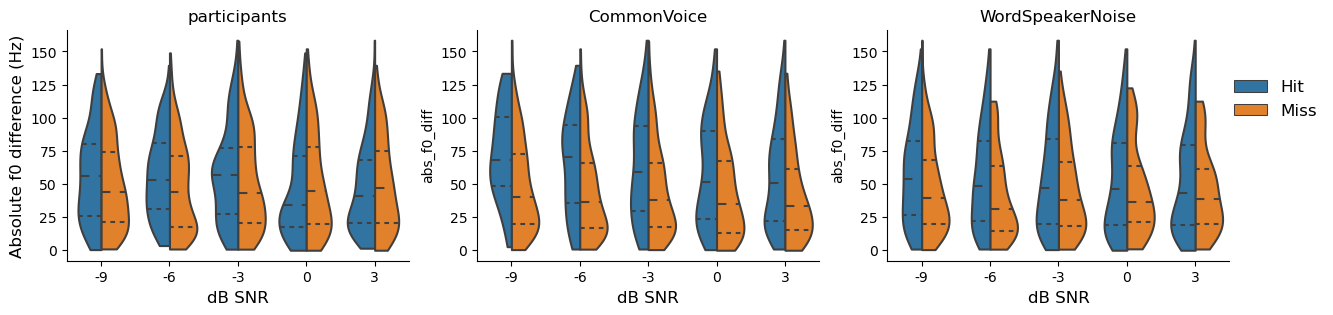

In [107]:
# g = sns.relplot(data=f0_analysis_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=f0_analysis_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
fig, axes = plt.subplots(1,3,figsize=(15,3))

for ix, group_name in enumerate(combined_f0_df.group.unique()):
    ax = sns.violinplot(data=combined_f0_df[combined_f0_df.group == group_name], x="snr", y="abs_f0_diff", cut=0, 
                        hue="correct_str", split=True, gap=.5, inner="quart", ax=axes[ix])

    ax.set_title(group_name)
    if ix < 2:
        ax.get_legend().remove()
    if ix == 0:
        ax.set_ylabel('Absolute f0 difference (Hz)', fontsize=fontsize)
    ax.set_xlabel('dB SNR', fontsize=fontsize)


sns.move_legend(ax, title='',
                loc="center right", bbox_to_anchor=(1.3, .7),
                frameon=False, title_size=fontsize, fontsize=fontsize)
sns.despine()
# ax1.set_ylabel('% f0 difference', fontsize=fontsize)


In [108]:
combined_f0_df['f0_close'] = combined_f0_df['abs_f0_diff'] <= 25

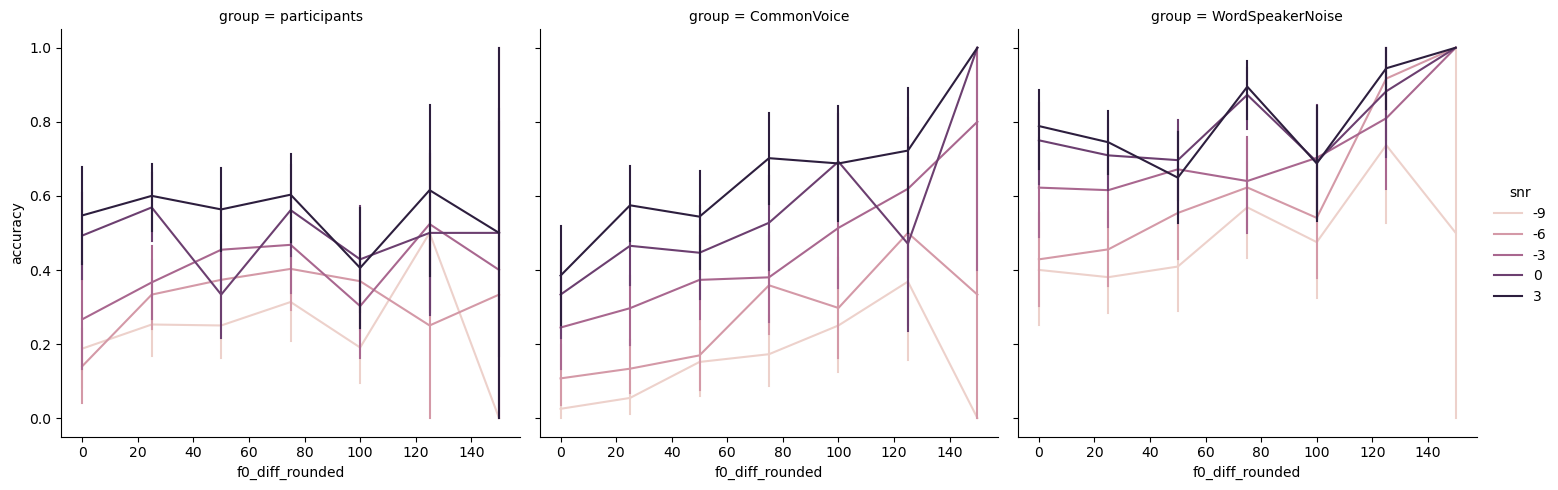

In [109]:
# g = sns.relplot(data=combined_f0_df, x='f0_diff', y='snr', hue='accuracy',  kind='scatter')
# sns.violinplot(data=combined_f0_df, x="snr", y="f0_diff", hue="accuracy", split=True, gap=.5, inner="quart")
# round abs f0 diff to nearest 12
to_plot = combined_f0_df[(combined_f0_df.background_condition == '1-talker')] 
to_plot["f0_diff_rounded"] = round(to_plot.abs_f0_diff / 25) * 25

ax = sns.relplot(data=to_plot, x="f0_diff_rounded", y="accuracy", hue='snr', col='group', 
                 kind='line', aspect=1, err_style="bars", errorbar=("ci",95),)
# sns.move_legend(ax, title='', 
#                 loc="center right", bbox_to_anchor=(1.5, .7),
#                 frameon=False, )
# sns.despine()
# sns.despine()
# ax.set_ylabel('f0 difference (Hz)', fontsize=fontsize)
# ax.set_xlabel('dB SNR', fontsize=fontsize)

In [118]:
# get trial data excluding catch trials 


f0_close_df = (combined_f0_df.groupby(["snr", 'id_subject', "f0_close"])
                     .agg({"accuracy":"mean", "adjusted_accuracy":"mean", "confusions": "mean", "adjusted_confusions":"mean"}, )
                     .reset_index())

# human_f0_close['group'] = 'participants'

f0_close_df.loc[~f0_close_df.id_subject.isin(['CommonVoice', "WordSpeakerNoise"]), 'group'] = 'Participants'
f0_close_df.loc[f0_close_df.id_subject == 'CommonVoice', 'group'] = "CommonVoice"
f0_close_df.loc[f0_close_df.id_subject == 'WordSpeakerNoise', 'group'] = "WordSpeakerNoise"

# model_f0_close = (combined_f0_df[combined_f0_df.group != 'model'].groupby(["snr", "f0_close"])
#                      .agg({"accuracy":"mean", "confusions": "mean"})
#                      .reset_index())
# model_f0_close['group'] = 'model'

# f0_close_df = pd.concat([human_f0_close, model_f0_close], axis=0,ignore_index=True)
f0_close_df.loc[f0_close_df.snr == np.inf, 'snr'] = 6
f0_close_df.loc[f0_close_df.snr == "inf", 'snr'] = 6
f0_close_df.loc[f0_close_df.snr == 6, "f0_close"] = "clean"
f0_close_df.loc[f0_close_df.snr == 6, "background_condition"] = "clean"
f0_close_df.loc[f0_close_df.snr < 6, "background_condition"] = "1-talker"



/tmp/ipykernel_1260090/3880386776.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(data=f0_close_df, x='snr', y='accuracy', hue='f0_close', hue_order=[False, True], kind='line', col='group', col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],


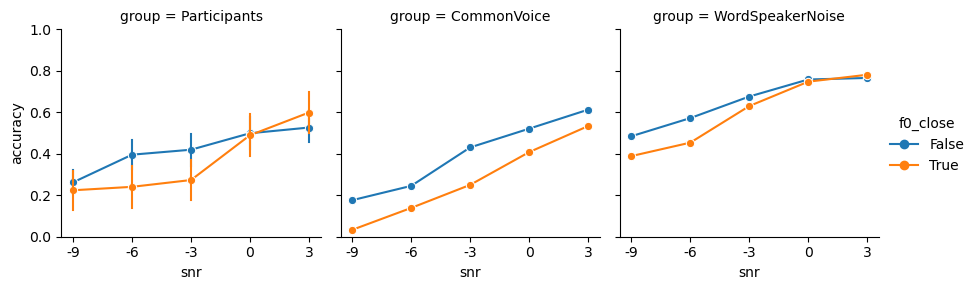

In [119]:
g = sns.relplot(data=f0_close_df, x='snr', y='accuracy', hue='f0_close', hue_order=[False, True], kind='line', col='group', col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],
                err_style = 'bars', style="f0_close", markers="o", dashes=False, errorbar=('se', 2), height=3)

x_tick_locs = f0_close_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'

for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


/tmp/ipykernel_1260090/1514374341.py:1: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(data=f0_close_df, x='snr', y='adjusted_accuracy', hue='f0_close', hue_order=[False, True], kind='line', col='group', col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],


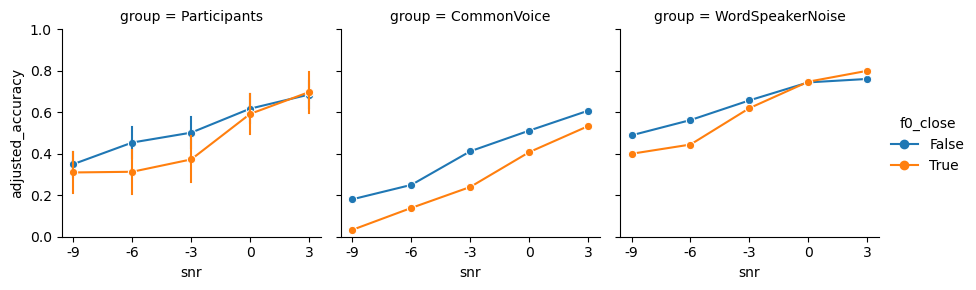

In [120]:
g = sns.relplot(data=f0_close_df, x='snr', y='adjusted_accuracy', hue='f0_close', hue_order=[False, True], kind='line', col='group', col_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'],
                err_style = 'bars', style="f0_close", markers="o", dashes=False, errorbar=('se', 2), height=3)

x_tick_locs = f0_close_df.snr.unique()
x_tick_labels = [str(x) for x in x_tick_locs]
# x_tick_labels[-1] = 'inf'

for ax in g.axes.flat:
# labels = ax.get_xticklabels() # get x labels
    ax.set_xticks(ticks=x_tick_locs) # set new labels
    ax.set_xticklabels(labels=x_tick_labels)
    plt.ylim(0,1)


In [121]:
combined_f0_df.columns

Index(['time_elapsed', 'internal_node_id', 'output_filename', 'id_random',
       'id_study', 'id_subject', 'id_session', 'id_version', 'hc_passed', 'rt',
       'response', 'stimulus', 'response_str', 'correct_response', 'correct',
       'n_correct', 'n_incorrect', 'snr', 'background_condition', 'accuracy',
       'base_str', 'target_gender', 'target_f0', 'distractor_f0',
       'distractor_gender', 'distractor_word', 'target_transcript',
       'distractor_transcript', 'confusions', 'adjusted_accuracy',
       'adjusted_confusions', 'gender_cond', 'abs_f0_diff', 'percent_f0_diff',
       'group', 'pred_word_int', 'true_word_int', 'model', 'pred_word',
       'true_word', 'word', 'word_int', 'correct_str', 'f0_close'],
      dtype='object')

In [122]:
# get trial data excluding catch trials 

gender_cond_df = (combined_f0_df.groupby(["background_condition", "snr", 'id_subject', "gender_cond"])
                     .agg({"adjusted_accuracy":"mean", "adjusted_confusions": "mean"})
                     .reset_index())

# human_f0_close['group'] = 'participants'

gender_cond_df.loc[~gender_cond_df.id_subject.isin(['CommonVoice', "WordSpeakerNoise"]), 'group'] = 'Participants'
gender_cond_df.loc[gender_cond_df.id_subject == 'CommonVoice', 'group'] = "CommonVoice"
gender_cond_df.loc[gender_cond_df.id_subject == 'WordSpeakerNoise', 'group'] = "WordSpeakerNoise"


gender_cond_df.loc[gender_cond_df.snr == np.inf, 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == "inf", 'snr'] = 6
gender_cond_df.loc[gender_cond_df.snr == 6, "gender_cond"] = "clean"
# gender_cond_df.loc[gender_cond_df.snr == 6, "background_condition"] = "clean"
# gender_cond_df.loc[gender_cond_df.snr < 6, "background_condition"] = "1-talker"

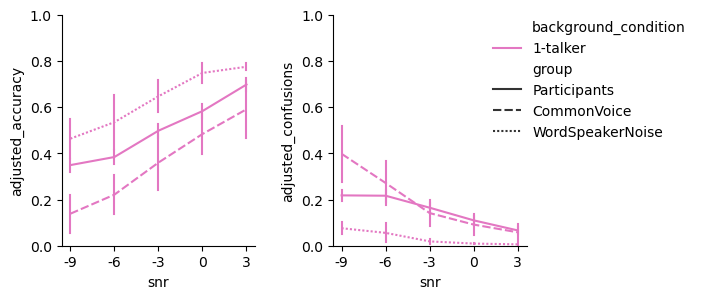

In [123]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

g = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 1),
                  style='group', style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='background_condition', palette=palette,
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 1),
                   style='group',style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                   hue='background_condition', palette=palette,
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()

# remove legend titles 
g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0., title='')


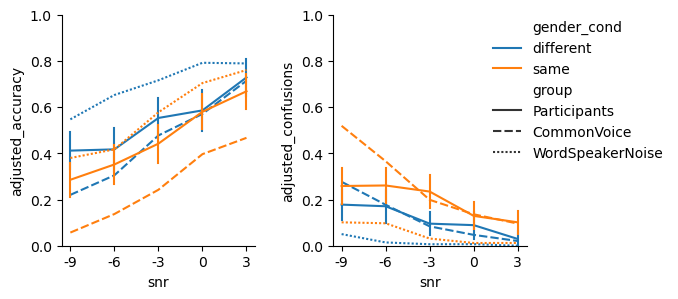

In [115]:
fig, axs = plt.subplots(1,2, figsize=(6,3))

g = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_accuracy', err_style='bars', errorbar=('se', 2),
                  style='group', style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='gender_cond',
            ax=axs[0])

g1 = sns.lineplot(data=gender_cond_df, x = 'snr', y = 'adjusted_confusions',  err_style='bars', errorbar=('se', 2),
                   style='group',style_order=['Participants', 'CommonVoice', 'WordSpeakerNoise'], 
                  hue='gender_cond',
            ax=axs[1])

g.set_xticks(ticks=x_tick_locs) # set new labels
g1.set_xticks(ticks=x_tick_locs) # set new labels
g.set_xticklabels(labels=x_tick_labels)
g1.set_xticklabels(labels=x_tick_labels)
g.set_ylim(0,1)
g1.set_ylim(0,1)
g.legend().remove()     
# add space between plots
plt.subplots_adjust(wspace=0.4)
sns.despine()
# remove legend titles 

g1.legend_.set_title('')
g1.legend(frameon=False, bbox_to_anchor=(.8, 1), loc=2, borderaxespad=0., title='')
